In [1]:
import pandas as pd
import numpy as np
import kagglehub
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

# Загрузка данных

In [20]:
os.environ["KAGGLEHUB_CACHE"] = "data/kagglehub_cache"

path = kagglehub.dataset_download(
    "egorkainov/moscow-housing-price-dataset"
)

print("Dataset path:", path)

df = pd.read_csv(path + "/data.csv")

print(df.head())
print(df.info())
print(df.describe())
duplicates_count = df.duplicated().sum()
print(f"\nКоличество дубликатов: {duplicates_count}")

Dataset path: data/kagglehub_cache\datasets\egorkainov\moscow-housing-price-dataset\versions\1
        Price Apartment type Metro station  Minutes to metro         Region  \
0   6300000.0      Secondary       Опалиха               6.0  Moscow region   
1   9000000.0      Secondary       Павшино               2.0  Moscow region   
2  11090000.0      Secondary      Мякинино              14.0  Moscow region   
3   8300000.0      Secondary      Строгино               8.0  Moscow region   
4   6450000.0      Secondary       Опалиха               6.0  Moscow region   

   Number of rooms  Area  Living area  Kitchen area  Floor  Number of floors  \
0              1.0  30.6         11.1           8.5   25.0                25   
1              1.0  49.2         20.0          10.0    6.0                15   
2              1.0  44.7         16.2          13.1   10.0                25   
3              1.0  35.1         16.0          11.0   12.0                33   
4              1.0  37.7      

In [22]:
df.drop_duplicates(inplace=True)
print(df.info())
duplicates_count = df.duplicated().sum()
print(f"\nКоличество дубликатов: {duplicates_count}")

<class 'pandas.DataFrame'>
Index: 20841 entries, 0 to 22675
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             20841 non-null  float64
 1   Apartment type    20841 non-null  str    
 2   Metro station     20841 non-null  str    
 3   Minutes to metro  20841 non-null  float64
 4   Region            20841 non-null  str    
 5   Number of rooms   20841 non-null  float64
 6   Area              20841 non-null  float64
 7   Living area       20841 non-null  float64
 8   Kitchen area      20841 non-null  float64
 9   Floor             20841 non-null  float64
 10  Number of floors  20841 non-null  int64  
 11  Renovation        20841 non-null  str    
dtypes: float64(7), int64(1), str(4)
memory usage: 3.1 MB
None

Количество дубликатов: 0


# Визуализация данных

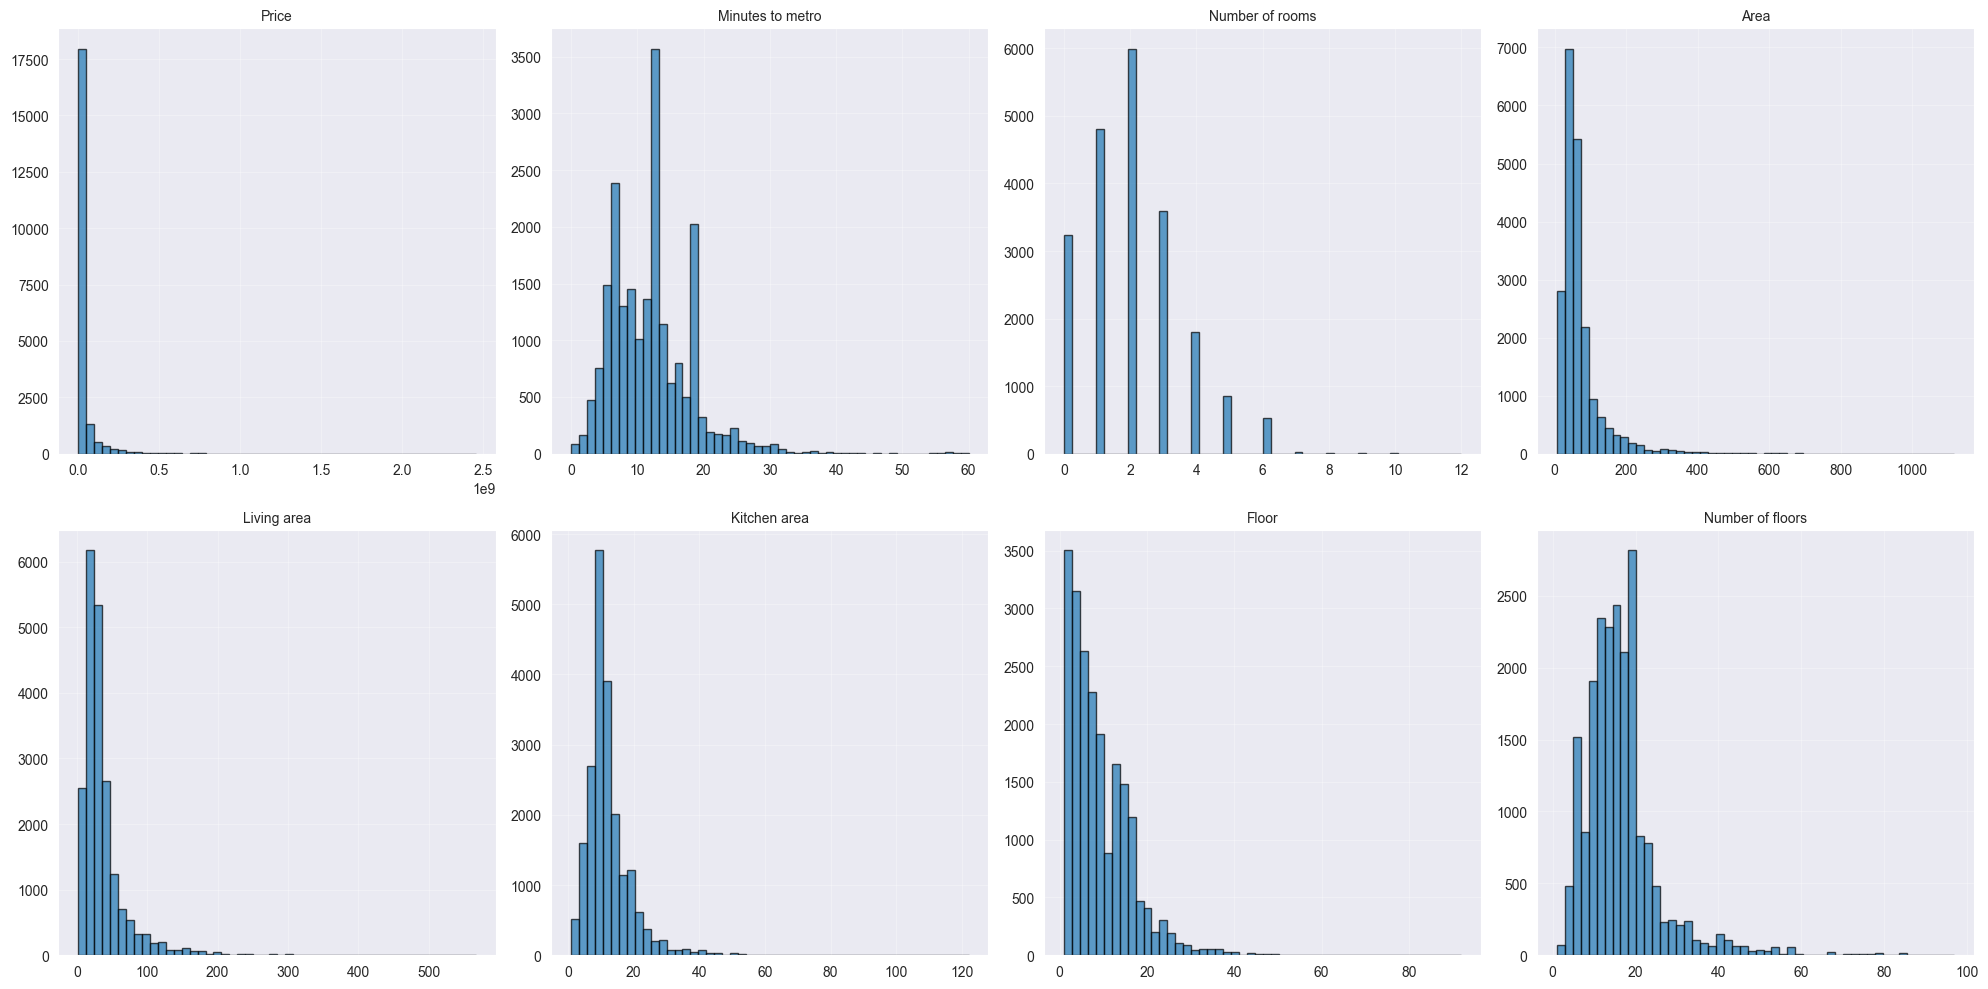

In [31]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=50, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Проверка корреляций признаков
Корреляции с целевой колонкой

ТОП-10 корреляций с Price:
Price               1.000000
Area                0.791157
Living area         0.714046
Kitchen area        0.560227
Number of rooms     0.475249
Minutes to metro    0.093501
Floor               0.020287
Number of floors    0.017472
Name: Price, dtype: float64




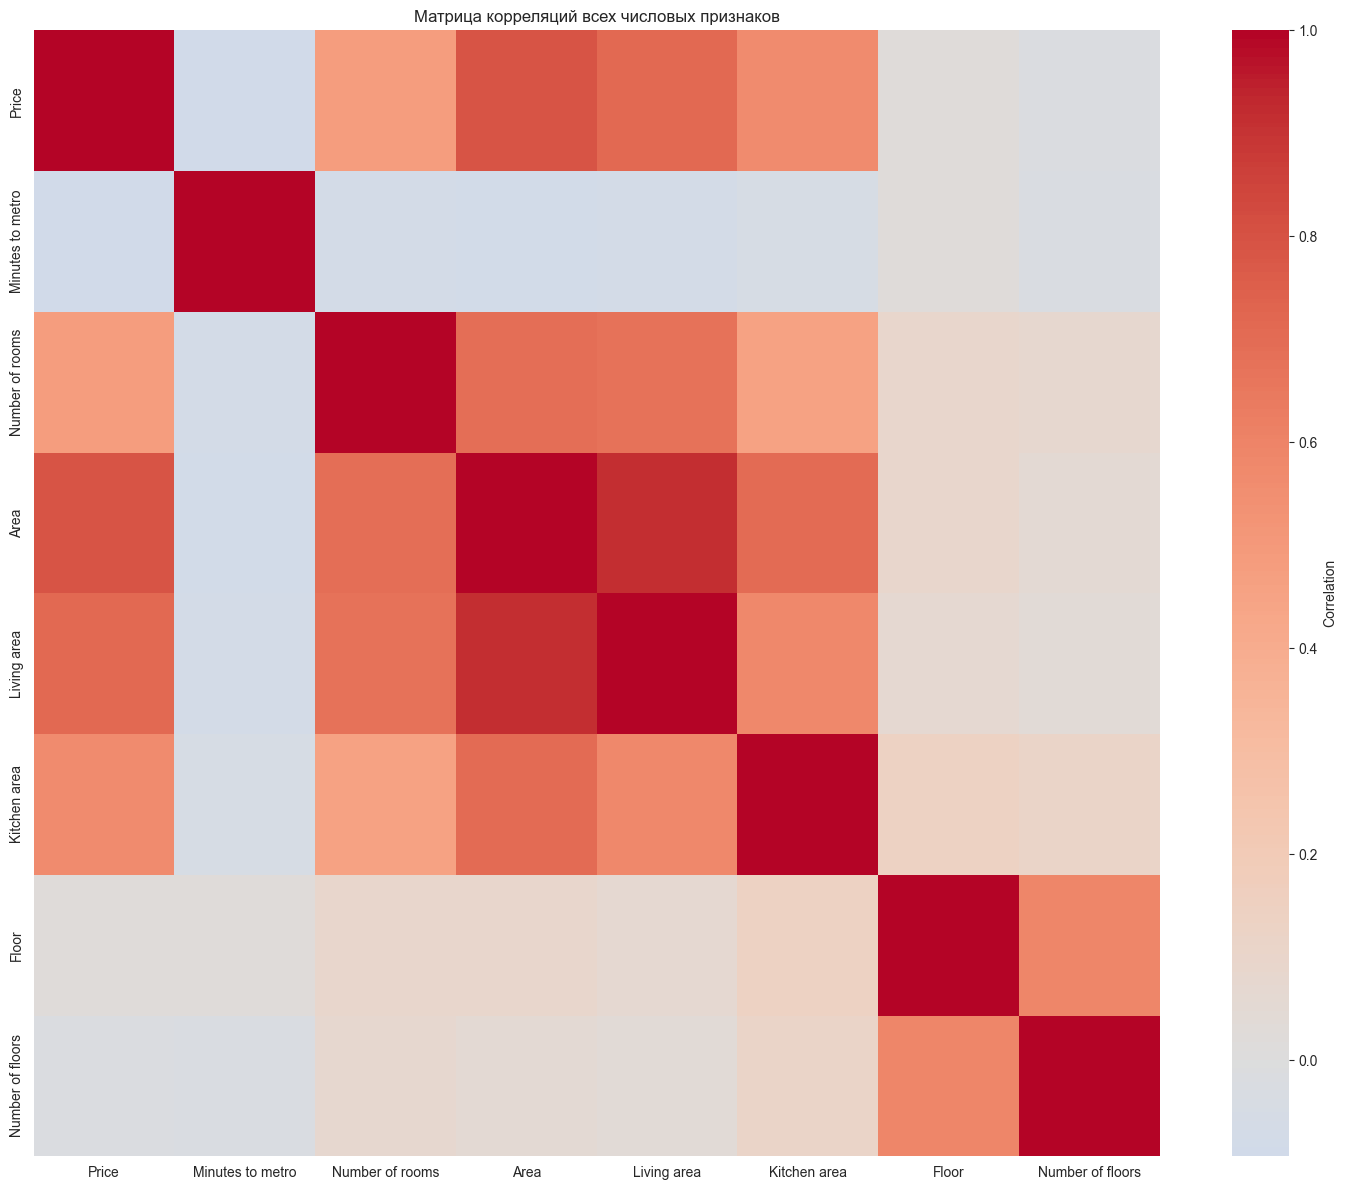

In [23]:
target = "Price"
numeric_df = df.select_dtypes(include=[np.number])

target_corr = numeric_df.corr()[target].abs().sort_values(ascending=False)
print("ТОП-10 корреляций с Price:")
print(target_corr.head(10))
print("\n" + "="*60 + "\n")

plt.figure(figsize=(15, 12))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', center=0,
            square=True, cbar_kws={'label': 'Correlation'})
plt.title('Матрица корреляций всех числовых признаков')
plt.tight_layout()
plt.show()

Взаимные корреляции

In [24]:
corr_matrix = numeric_df.corr()
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_val
            ))

print("Пары с высокой корреляцией")
for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"{feat1:25} - {feat2:25} = {corr:.4f}")

Пары с высокой корреляцией
Living area               - Area                      = 0.9139


# Подготовка выборок

In [25]:
target_col = "Price"
exclude_cols = [target_col, "Area"]

feature_cols = df.columns

print("Все признаки до очистки:", feature_cols)
print(f"Количество признаков до очистки: {len(feature_cols)}")

feature_cols = [col for col in feature_cols if col not in exclude_cols]
print("\nИспользуемые признаки:", feature_cols)

X = df[feature_cols]
y = df[target_col]

# Разбиение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42, shuffle=True
)

# Категориальные и числовые
numeric_features = [
    'Minutes to metro', 'Number of rooms',
    'Living area', 'Kitchen area', 'Floor', 'Number of floors'
]
categorical_features = ['Apartment type', 'Metro station', 'Region', 'Renovation']

print(f"Числовых признаков: {len(numeric_features)}")
print(f"Категорий категориальных: {len(categorical_features)}") 

Все признаки до очистки: Index(['Price', 'Apartment type', 'Metro station', 'Minutes to metro',
       'Region', 'Number of rooms', 'Area', 'Living area', 'Kitchen area',
       'Floor', 'Number of floors', 'Renovation'],
      dtype='str')
Количество признаков до очистки: 12

Используемые признаки: ['Apartment type', 'Metro station', 'Minutes to metro', 'Region', 'Number of rooms', 'Living area', 'Kitchen area', 'Floor', 'Number of floors', 'Renovation']
Числовых признаков: 6
Категорий категориальных: 4


# Предобработка данных

In [26]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

# Random Forest
Модель

In [27]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(
        n_estimators=150,
        max_depth=10,
        min_samples_split=40,
        min_samples_leaf=20,
        random_state=42
    ))
])

Обучение

In [28]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.4f}')


RMSE: 45786875.34
R²: 0.6217


# Gradient Boosting on Decision Tree
Модель

In [29]:
categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

gbdt = HistGradientBoostingRegressor(
    learning_rate=0.1,
    max_depth=8,
    max_iter=300,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42,
    early_stopping=True
)
pipe_gbdt = Pipeline([
    ('preprocessor', preprocessor),  # тот же, что и раньше (скейлер + OneHotEncoder)
    ('gbdt', gbdt)
])

GBDT RMSE: 42644514.53
GBDT R²: 0.6719


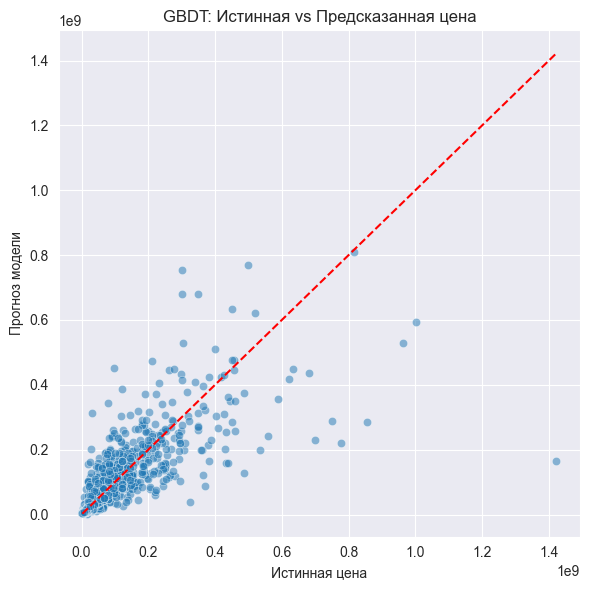

In [30]:
pipe_gbdt.fit(X_train, y_train)
y_pred_gbdt = pipe_gbdt.predict(X_test)

rmse_gbdt = np.sqrt(mean_squared_error(y_test, y_pred_gbdt))
r2_gbdt = r2_score(y_test, y_pred_gbdt)

print(f"GBDT RMSE: {rmse_gbdt:.2f}")
print(f"GBDT R²: {r2_gbdt:.4f}")

# Визуализация соотношения истинных и предсказанных значений
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_gbdt, alpha=0.5)
plt.xlabel("Истинная цена")
plt.ylabel("Прогноз модели")
plt.title("GBDT: Истинная vs Предсказанная цена")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.tight_layout()
plt.show()